In [74]:
from google.colab import files
from google.colab import drive
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
path="/content/drive/MyDrive/Colab Notebooks/Archivos_comp_1/millas_por_galon.csv"
filename1 = pd.read_csv((path))
filename1.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [42]:
dfcarro = filename1[["mpg", "horsepower"]]
dfcarro.head()

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0


In [61]:
df_usa = filename1[filename1["origin"]=="usa"]
df_europe = filename1[filename1["origin"]=="europe"]
df_japan = filename1[filename1["origin"]=="japan"]

Observamos que existen 9 variables

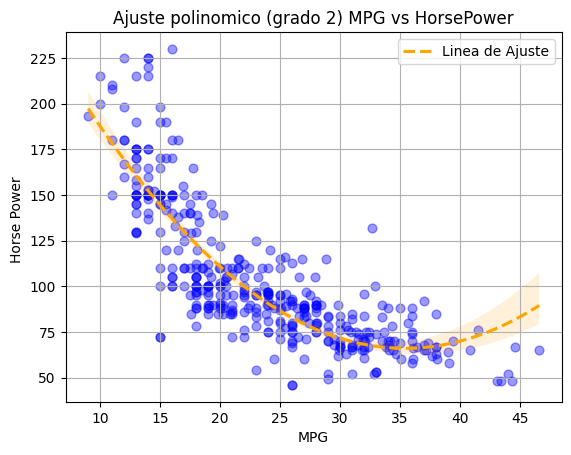

In [50]:
sns.regplot(data=dfcarro, x = "mpg", y = "horsepower", ci=95, order=2,
             scatter_kws={"color": "blue", "alpha": 0.4, "s": 40},
             line_kws={"color": "orange", "ls":"dashed","label":"Linea de Ajuste"})
plt.title("Ajuste polinomico (grado 2) MPG vs HorsePower")
plt.xlabel("MPG")
plt.ylabel("Horse Power ")
plt.legend()
plt.grid()
plt.show()

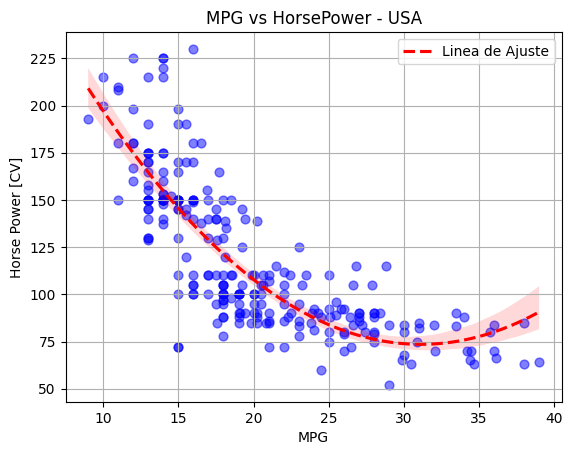

In [81]:
# Analisis USA

sns.regplot(data=df_usa, x = "mpg", y = "horsepower", ci=95, order=2,
             scatter_kws={"color": "blue", "alpha": 0.5, "s": 40},
             line_kws={"color": "red", "ls":"dashed","label":"Linea de Ajuste"})
plt.title("MPG vs HorsePower - USA")
plt.xlabel("MPG")
plt.ylabel("Horse Power [CV]")
plt.legend()
plt.grid()
plt.show()

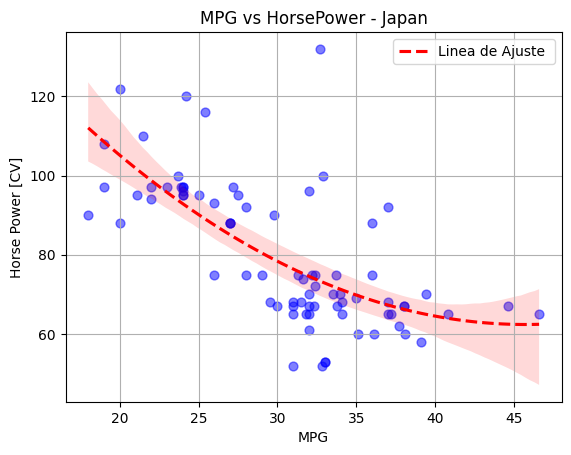

In [82]:
sns.regplot(data=df_japan, x = "mpg", y = "horsepower", ci=95, order=2,
             scatter_kws={"color": "blue", "alpha": 0.5, "s": 40},
             line_kws={"color": "red", "ls":"dashed","label":"Linea de Ajuste "})
plt.title("MPG vs HorsePower - Japan")
plt.xlabel("MPG")
plt.ylabel("Horse Power [CV]")
plt.legend()
plt.grid()
plt.show()

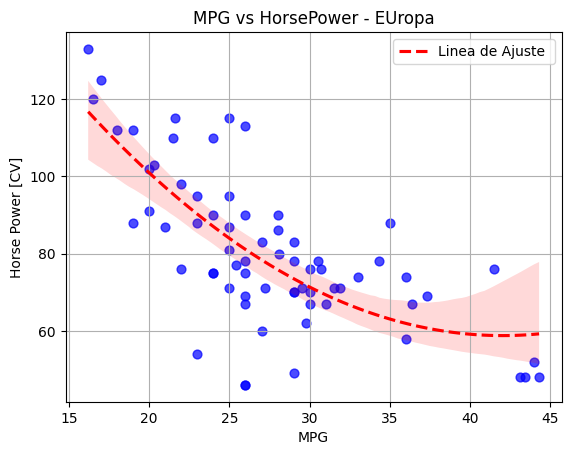

In [80]:
sns.regplot(data=df_europe, x = "mpg", y = "horsepower", ci=95, order=2,
             scatter_kws={"color": "blue", "alpha": 0.7, "s": 40},
             line_kws={"color": "red", "ls":"dashed","label":"Linea de Ajuste "})
plt.title("MPG vs HorsePower - EUropa")
plt.xlabel("MPG")
plt.ylabel("Horse Power [CV]")
plt.legend()
plt.grid()
plt.show()

Para el caso de USA vemosque al ser muchos datos se ajusta de una manera más "fiel a la linea de ajuste." Poseen ademas muchos vehiculos que al tener una gran capaicdade de tanque (MPG) su potencia en caballos de fuerza es menor. A diferencia con japón que han priorizado estar en un rango de 25 a 30 MPG que es donde se concentran la mayor cantidad de datos.

Por otro lado Europa ha diversificado en gran medida sus datos por la gran cantidad de marcas que existen a lo largo de los países europeos.


FALTO LAS ECUACIONES DE LOS POLINOMIOS...

In [37]:
path2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Archivos_comp_1/general-scan.csv")
path2.head()

,Unnamed: 0,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,...,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.0,0.217236,702.109163,...,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.0,0.019173,329.668504,...,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816
2,2,452.875632,2.469280e+06,2.469280e+06,0.000490,0.000490,0.017861,0.0,0.337367,3843.138599,...,0.000638,0.0,4.833919e-18,1.220000e-26,0.999994,-0.003384,0.003384,0.999994,0.002822,0.000000
3,3,589.443344,9.826674e+07,9.826674e+07,0.042790,0.042790,0.031174,0.0,0.270921,314.258778,...,0.000181,0.0,9.406560e-16,2.740000e-30,0.979480,-0.201541,0.201541,0.979480,0.002838,0.000194
4,4,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.0,0.046671,13048.623894,...,0.000066,0.0,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000


In [38]:
path2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17396 entries, 0 to 17395
Data columns (total 60 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  17396 non-null  int64  
 1   MDF         17396 non-null  float64
 2   MS12        17396 non-null  float64
 3   MS22        17396 non-null  float64
 4   LamS1H      17396 non-null  float64
 5   LamS2H      17396 non-null  float64
 6   LamSPH      17396 non-null  float64
 7   LamS        17396 non-null  float64
 8   LamSP       17396 non-null  float64
 9   vS          17396 non-null  float64
 10  YRD         17396 non-null  float64
 11  YRC         17396 non-null  float64
 12  YRA11       17396 non-null  float64
 13  YRA12       17396 non-null  float64
 14  YRA13       17396 non-null  float64
 15  YRA21       17396 non-null  float64
 16  YRA22       17396 non-null  float64
 17  YRA23       17396 non-null  float64
 18  YRB11       17396 non-null  float64
 19  YRB12       17396 non-nul

In [69]:
# Creamos la columna para M_n

path2["MN"] = path2['vS']*(path2["YRC"])/np.sqrt(2)

vS = path2["vS"]
h_c = path2["YRC"]
MN = path2["MN"]
M_phi = path2['MDF']
m_chi1 = path2['mChi1']
omega = path2['Omega']
omega_dm = 0.12

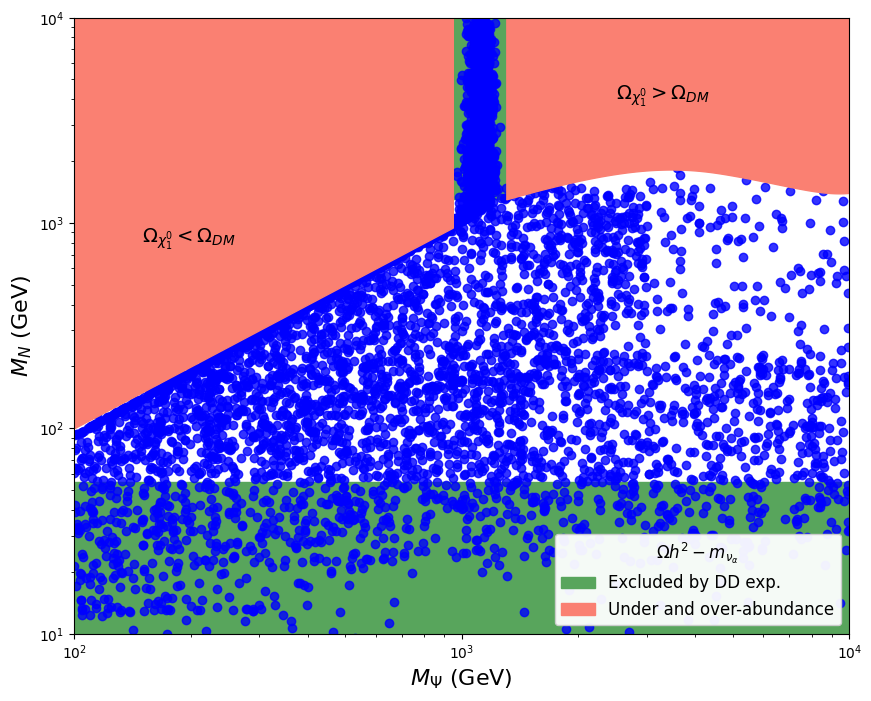

In [76]:
plt.figure(figsize=(10, 8))


# Configuración de las regiones

x_fill = np.logspace(2, 4, 1000)
x_column_start = 950
x_column_end = 1300
y_column_base = 1300

# Zona verde

plt.fill_between([100, 10000], 10, 55, color='#58A55C', alpha=1, label='Excluded by DD exp.',zorder=0)
plt.fill_between([x_column_start, x_column_end], y_column_base, 10000, color='#58A55C', alpha=1, zorder=0)

# Zona rosada

plt.fill_between(x_fill, x_fill, 10000, where=(x_fill <= x_column_start), zorder = 2,
                 color='#FA8072', alpha=1, label='Under and over-abundance')

x_curve = [x_column_end, 2000, 3000, 5000, 7000, 10000]
y_curve = [y_column_base, 1600, 1800, 1700, 1500, 1400]
f_interp = interp1d(x_curve, y_curve, kind='cubic', fill_value="extrapolate")

plt.fill_between(x_fill, f_interp(x_fill), 10000,
                 where=(x_fill >= x_column_end),
                 zorder=2,
                 color='#FA8072', alpha=1)

# Puntos (grafica scatter) y configuración de legenda y ejes.

sns.regplot(data=path2, x=M_phi, y=MN,
            scatter_kws={"color":"blue"})
plt.xscale("log")
plt.yscale("log")
plt.xlim(100, 10000)
plt.ylim(10, 10000)
plt.xlabel(r'$M_\Psi$ (GeV)', fontsize=16)
plt.ylabel(r'$M_N$ (GeV)', fontsize=16)
plt.text(150, 800, r'$\Omega_{\chi_1^0} < \Omega_{DM}$', fontsize=14, weight='bold')
plt.text(2500, 4000, r'$\Omega_{\chi_1^0} > \Omega_{DM}$', fontsize=14, weight='bold')
plt.legend(title=r'$\Omega h^2 - m_{\nu_\alpha}$', loc='lower right', framealpha=0.95, fontsize=12, title_fontsize=12)
plt.show()

NOTA 2.2+2.3
EN ESTE SEGUNDO NO HAY FILTRADO CON PANDAS... SOLO EL FILBETWEEN...